### Problem 1 - Approximation of integrals II

Consider the integral

$$I = \int_{0}^{3}\int_{0}^{2}e^{-(x+y)^{2}}dydx$$

a) Trying to find the value of $I$ using numerical integration.

In [2]:
from scipy import integrate
import numpy as np

function = lambda x, y: np.exp(-(x+y)**2)

result, error = integrate.dblquad(function, 0, 3, lambda x: 0, lambda x: 2)

print(f"Numerical integration: {result}")
print(f"Estimated error: {error}")

Numerical integration: 0.4991302766141038
Estimated error: 1.2514356126150874e-12


b) Simulating the standard deviation of the monte carlo approximation using one sample.

In [3]:
import numpy as np

def integrand(x, y):
	return np.exp(-(x+y)**2)


N = 1000000

X = np.random.uniform(0, 3, size=N)
Y = np.random.uniform(0, 2, size=N)

Z = 6*integrand(X, Y)

sigma_bar = np.sqrt(np.mean(Z**2) - np.mean(Z)**(2))

print(f"Standard Deviation = {sigma_bar}")


Standard Deviation = 1.1166664514783566


c) Plotting numbers.

0.06457864795405743


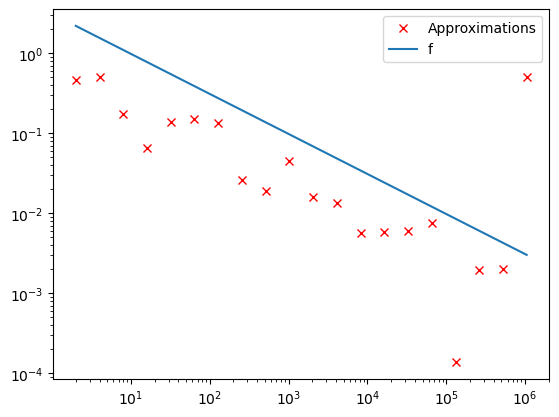

In [22]:
import numpy as np
from matplotlib import pyplot as plt

def integrand(x, y):
	return np.exp(-(x+y)**2)

def f(sigma, k):
	return 1.96*sigma/2**(k/2)

def approximation(f1, N, x_low=0, x_high=1, y_low=0, y_high=1):
	X = np.random.uniform(x_low, x_high, size=N)
	Y = np.random.uniform(y_low, y_high, size=N)
	return np.sum(f1(X, Y))*abs(x_high - x_low)*abs(y_high - y_low)/N

N = 1000
Z_prime = np.zeros((20, 1))

for k in range(1, 20):
	Z_prime[k-1] = approximation(integrand, 2**k, 0, 3, 0, 2)

Z_prime = abs(Z_prime - result)
print(Z_prime[3][0])

x_axis = 2**np.linspace(1, 20, 20)
y_axis = [f(sigma_bar, i) for i in range(len(x_axis))]

plt.figure(1)
plt.loglog(x_axis, Z_prime, "xr", label="Approximations")
plt.loglog(x_axis, y_axis, label="f")
plt.legend()

plt.show()